# mexari - Municipalities Edge Label Classification
Treat every observed municipality adjacency as a positive edge label and sample one non-adjacent municipality pair as a negative label for each positive example. The notebook then trains a balanced GNN-based edge classifier on those labels.


## 1 - Imports


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn

try:
    from torch_geometric.nn import BatchNorm, GCNConv
except ImportError as exc:
    raise ImportError(
        "This notebook requires `torch_geometric`. Install PyTorch and PyG before running it."
    ) from exc

import mexari as mx

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"mexari version : {mx.__version__}")
print(f"Bundled CSV    : {mx.DEFAULT_CSV}")
print(f"Torch version  : {torch.__version__}")
print(f"Torch device   : {device}")


mexari version : 0.1.0
Bundled CSV    : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/mortality_rates.csv
Torch version  : 2.11.0+cu128
Torch device   : cuda


## 2 - Build the graph from a local GeoJSON


In [20]:
# Update this path to point to your local municipalities GeoJSON file.
geojson_path = Path("../Data/mexico.geojson")

if not geojson_path.exists():
    raise FileNotFoundError(
        f"Set `geojson_path` to a local GeoJSON file before running the notebook: {geojson_path}"
    )

G = mx.build_graph(geojson_path=geojson_path)

print(f"Nodes   : {G.number_of_nodes()}")
print(f"Edges   : {G.number_of_edges()}")
print(f"Dates   : {len(G.graph['dates'])}")
print(f"Density : {nx.density(G):.5f}")


Nodes   : 2475
Edges   : 7246
Dates   : 1148
Density : 0.00237


In [21]:
sample = G.nodes[0]
print("Sample node attributes:")
for key, value in sample.items():
    if key in ("mortality", "features"):
        print(f"  {key}: {type(value).__name__} with {len(value)} entries")
    else:
        print(f"  {key}: {value}")


Sample node attributes:
  municipality: San José de Gracia
  state: Aguascalientes
  longitude: -102.52583871928235
  latitude: 22.146634606582133
  mortality: dict with 1148 entries
  features: ndarray with 1148 entries


## 3 - Create positive and negative edge labels


In [22]:
X_np, node_order = mx.get_node_feature_matrix(G)
X = torch.tensor(X_np, dtype=torch.float32)
X = (X - X.mean(dim=0, keepdim=True)) / (X.std(dim=0, keepdim=True) + 1e-6)
node_to_idx = {node: idx for idx, node in enumerate(node_order)}

positive_edges = sorted({tuple(sorted((u, v))) for u, v in G.edges()})

def sample_negative_edges(graph, num_samples, seed=7):
    rng = np.random.default_rng(seed)
    nodes = np.array(list(graph.nodes()), dtype=np.int64)
    existing = {tuple(sorted((u, v))) for u, v in graph.edges()}
    negatives = set()

    while len(negatives) < num_samples:
        u, v = rng.choice(nodes, size=2, replace=False)
        edge = tuple(sorted((int(u), int(v))))
        if edge in existing or edge in negatives:
            continue
        negatives.add(edge)

    return sorted(negatives)

def split_edges(edges, train_ratio=0.6, val_ratio=0.2, seed=7):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(edges))
    shuffled = [edges[i] for i in order]

    train_end = int(len(shuffled) * train_ratio)
    val_end = train_end + int(len(shuffled) * val_ratio)

    return {
        "train": shuffled[:train_end],
        "val": shuffled[train_end:val_end],
        "test": shuffled[val_end:],
    }

def build_edge_label_tensors(node_lookup, pos_edges, neg_edges, seed=7):
    edge_pairs = pos_edges + neg_edges
    labels = [1] * len(pos_edges) + [0] * len(neg_edges)

    rng = np.random.default_rng(seed)
    order = rng.permutation(len(edge_pairs))

    indexed_pairs = [
        (node_lookup[edge_pairs[i][0]], node_lookup[edge_pairs[i][1]])
        for i in order
    ]
    shuffled_labels = [labels[i] for i in order]

    edge_label_index = torch.tensor(indexed_pairs, dtype=torch.long).T.contiguous()
    edge_label = torch.tensor(shuffled_labels, dtype=torch.float32)

    return edge_label_index, edge_label

print(f"Node feature matrix X : {tuple(X.shape)}")
print(f"Positive edges        : {len(positive_edges)}")


Node feature matrix X : (2475, 1148)
Positive edges        : 7246


In [23]:
negative_edges = sample_negative_edges(G, num_samples=len(positive_edges), seed=7)

positive_split = split_edges(positive_edges, seed=7)
negative_split = split_edges(negative_edges, seed=13)

train_graph = nx.Graph()
train_graph.add_nodes_from(G.nodes(data=True))
train_graph.add_edges_from(positive_split["train"], weight=1.0)

message_passing_edge_index = torch.tensor(
    mx.get_edge_index(train_graph, node_order),
    dtype=torch.long,
)

split_tensors = {}
for split_name in ("train", "val", "test"):
    edge_label_index, edge_label = build_edge_label_tensors(
        node_lookup=node_to_idx,
        pos_edges=positive_split[split_name],
        neg_edges=negative_split[split_name],
        seed=7 + len(split_name),
    )
    split_tensors[split_name] = {
        "edge_label_index": edge_label_index,
        "edge_label": edge_label,
    }

summary = pd.DataFrame(
    {
        "positive": {name: len(edges) for name, edges in positive_split.items()},
        "negative": {name: len(edges) for name, edges in negative_split.items()},
    }
)
summary["total"] = summary["positive"] + summary["negative"]

print(f"Training graph edges used for message passing : {train_graph.number_of_edges()}")
print(f"Directed message-passing edges                : {message_passing_edge_index.shape[1]}")
summary


Training graph edges used for message passing : 4347
Directed message-passing edges                : 8694


,positive,negative,total
train,4347,4347,8694
val,1449,1449,2898
test,1450,1450,2900


Only the training positive edges are used for message passing. Validation and test edges stay out of the graph structure so the edge-label evaluation is performed on held-out examples.


## 4 - Define the GNN edge classifier


In [24]:
class EdgeLabelGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, num_layers=3, dropout=0.25):
        super().__init__()
        torch.manual_seed(7)
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.norms.append(BatchNorm(hidden_channels))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.norms.append(BatchNorm(hidden_channels))

        self.edge_mlp = nn.Sequential(
            nn.Linear(hidden_channels * 4, hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Linear(hidden_channels // 2, 1),
        )

    def encode(self, x, edge_index):
        h = x
        for layer_idx, (conv, norm) in enumerate(zip(self.convs, self.norms)):
            h_next = conv(h, edge_index)
            h_next = norm(h_next)
            h_next = F.relu(h_next)
            if layer_idx > 0:
                h_next = h_next + h
            h = F.dropout(h_next, p=self.dropout, training=self.training)
        return h

    def decode(self, z, edge_label_index):
        src, dst = edge_label_index
        z_src, z_dst = z[src], z[dst]
        edge_features = torch.cat(
            [z_src, z_dst, torch.abs(z_src - z_dst), z_src * z_dst],
            dim=-1,
        )
        return self.edge_mlp(edge_features).squeeze(-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        logits = self.decode(z, edge_label_index)
        return logits, z

X = X.to(device)
message_passing_edge_index = message_passing_edge_index.to(device)
split_tensors = {
    name: {
        "edge_label_index": data["edge_label_index"].to(device),
        "edge_label": data["edge_label"].to(device),
    }
    for name, data in split_tensors.items()
}

model = EdgeLabelGCN(
    in_channels=X.shape[1],
    hidden_channels=128,
    num_layers=3,
    dropout=0.25,
).to(device)
print(model)


EdgeLabelGCN(
  (convs): ModuleList(
    (0): GCNConv(1148, 128)
    (1-2): 2 x GCNConv(128, 128)
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (edge_mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 5 - Train the model


In [25]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.004, weight_decay=1e-3)
patience = 35

def accuracy_from_logits(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).float()
    return (preds == labels).float().mean().item()

def evaluate_split(split_name):
    model.eval()
    with torch.no_grad():
        logits, _ = model(
            X,
            message_passing_edge_index,
            split_tensors[split_name]["edge_label_index"],
        )
        loss = criterion(logits, split_tensors[split_name]["edge_label"])
        acc = accuracy_from_logits(logits, split_tensors[split_name]["edge_label"])
    return loss.item(), acc, torch.sigmoid(logits).detach().cpu()

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_state = None
best_val_acc = -1.0
best_epoch = 0
epochs_without_improvement = 0

for epoch in range(1, 251):
    model.train()
    optimizer.zero_grad()

    train_logits, _ = model(
        X,
        message_passing_edge_index,
        split_tensors["train"]["edge_label_index"],
    )
    loss = criterion(train_logits, split_tensors["train"]["edge_label"])
    loss.backward()
    optimizer.step()

    train_acc = accuracy_from_logits(
        train_logits.detach(),
        split_tensors["train"]["edge_label"],
    )
    val_loss, val_acc, _ = evaluate_split("val")

    history["train_loss"].append(loss.item())
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0
        best_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 20 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={loss.item():.4f} | "
            f"train_acc={train_acc:.3f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.3f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch:03d}")
        break

model.load_state_dict(best_state)
print(f"Best validation accuracy: {best_val_acc:.3f} at epoch {best_epoch}")


Epoch 001 | train_loss=0.6980 | train_acc=0.504 | val_loss=0.6857 | val_acc=0.480
Epoch 020 | train_loss=0.1485 | train_acc=0.944 | val_loss=0.4159 | val_acc=0.863


Epoch 040 | train_loss=0.0533 | train_acc=0.981 | val_loss=0.7493 | val_acc=0.857
Epoch 060 | train_loss=0.0307 | train_acc=0.989 | val_loss=0.9213 | val_acc=0.860
Early stopping at epoch 062
Best validation accuracy: 0.871 at epoch 27


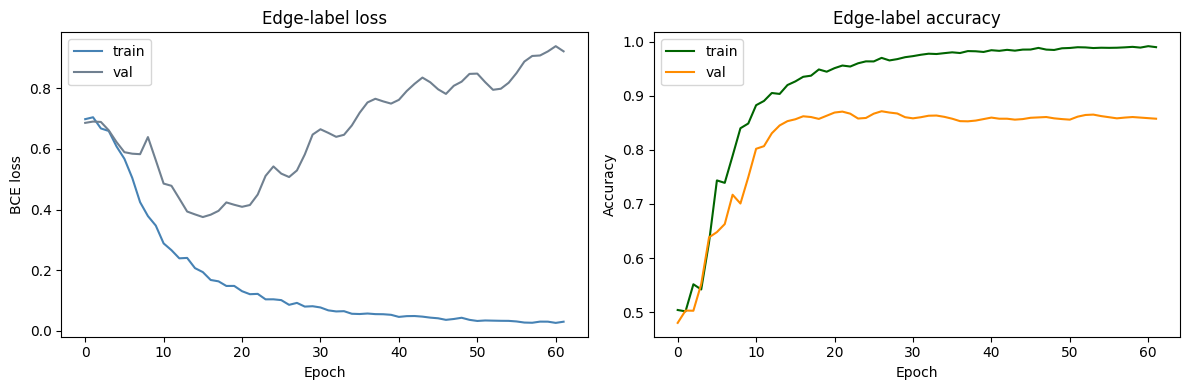

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train", color="steelblue")
axes[0].plot(history["val_loss"], label="val", color="slategray")
axes[0].set_title("Edge-label loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train", color="darkgreen")
axes[1].plot(history["val_acc"], label="val", color="darkorange")
axes[1].set_title("Edge-label accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6 - Evaluate on held-out edges


In [27]:
test_loss, test_acc, test_probs = evaluate_split("test")

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_acc:.3f}")

test_edge_pairs = split_tensors["test"]["edge_label_index"].T.detach().cpu().numpy()
test_labels = split_tensors["test"]["edge_label"].detach().cpu().numpy().astype(int)

preview = pd.DataFrame(
    {
        "source_node": [node_order[i] for i in test_edge_pairs[:, 0]],
        "target_node": [node_order[i] for i in test_edge_pairs[:, 1]],
        "label": test_labels,
        "pred_prob": np.round(test_probs.numpy(), 3),
    }
)
preview["pred_label"] = (preview["pred_prob"] >= 0.5).astype(int)
preview["correct"] = preview["pred_label"] == preview["label"]
preview["source_municipality"] = preview["source_node"].map(
    lambda node: G.nodes[node]["municipality"]
)
preview["target_municipality"] = preview["target_node"].map(
    lambda node: G.nodes[node]["municipality"]
)

preview.sort_values(["correct", "pred_prob"], ascending=[True, False]).head(10)


Test loss     : 0.4459
Test accuracy : 0.879


,source_node,target_node,label,pred_prob,pred_label,correct,source_municipality,target_municipality
52,1229,1735,0,1.0,1,False,San Bartolomé Yucuañe,Acatlán
58,1080,1576,0,1.0,1,False,San Vicente Nuñú,Valerio Trujano
157,2030,2400,0,1.0,1,False,Padilla,Tahdziú
432,1778,2460,0,1.0,1,False,Coatepec,Santa María de la Paz
437,1232,1410,0,1.0,1,False,Santo Domingo Tonaltepec,San Pedro Yaneri
496,1498,1664,0,1.0,1,False,Santa María Yavesía,Chila de la Sal
899,575,656,0,1.0,1,False,Cañadas de Obregón,San Cristóbal de la Barranca
999,1762,1997,0,1.0,1,False,La Magdalena Tlatlauquitepec,Mier
1283,1210,1785,0,1.0,1,False,San Baltazar Chichicápam,Chigmecatitlán
1287,215,231,0,1.0,1,False,Matamoros,Huejotitán
